# 异步电机转矩–转差率（T–s）特性

> **电机学教学演示系列 · 样章（兼模板）**
> 适用对象：本科《电机学》课堂演示 ｜ 符号体系参考：汤蕴璆《电机学》 ｜ 全部物理量采用 SI 单位
>
> **本章结构**：一、现象引入 → 二、公式推导 → 三、交互实验区 → 四、思考题
>
> 后续章节复制本 notebook 后，只需替换「模型参数与计算函数」和「绘图函数」两个代码 cell 即可复用整体框架。

In [1]:
# ================= 环境准备：导入库 + matplotlib 全局样式 =================
import numpy as np
import matplotlib.pyplot as plt

# 中文字体（Windows 自带微软雅黑 / 黑体），并修复负号 "-" 显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 投屏可读性：字号不小于 14，坐标轴加粗，默认开网格线
plt.rcParams.update({
    'font.size': 15,          # 正文字号
    'axes.titlesize': 17,     # 图标题
    'axes.labelsize': 16,     # 坐标轴标签
    'xtick.labelsize': 14,    # 刻度
    'ytick.labelsize': 14,
    'legend.fontsize': 14,    # 图例
    'axes.linewidth': 1.8,    # 坐标轴加粗
    'axes.grid': True,        # 默认开启网格线
    'grid.alpha': 0.4,
    'lines.linewidth': 3.0,   # 曲线默认线宽
})

## 一、现象引入

三相异步电机运行时，定子旋转磁场以同步转速 $n_1$ 旋转，而转子转速 $n$ 总是略低于 $n_1$。正是这个"转速差"在转子导体中感应出电动势与电流，进而产生电磁转矩。转差率 $s=(n_1-n)/n_1$ 衡量这种"打滑"程度：空载时 $s$ 接近 0，堵转（启动瞬间）时 $s=1$。**转矩随转差率变化的 $T-s$ 曲线，是理解异步电机全部运行特性的钥匙。**

运行下面的代码，观察转差率的物理图像：

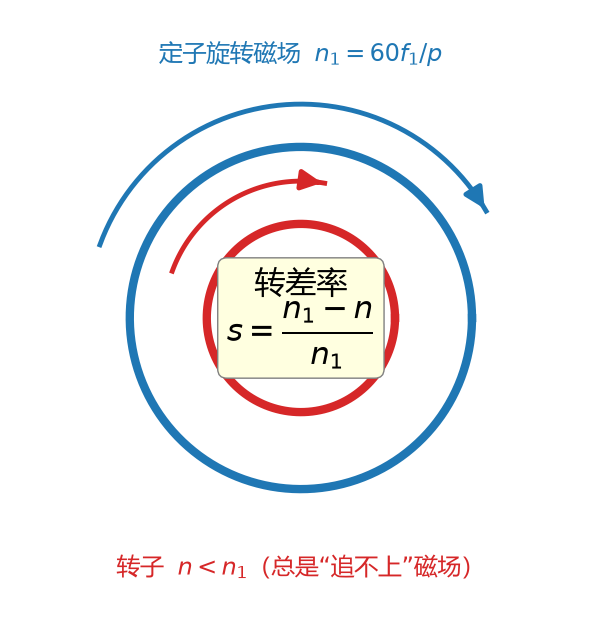

In [2]:
# ================= 静态示意图：转差率的物理图像 =================
# 外圈 = 定子（产生同步转速 n1 的旋转磁场），内圈 = 转子（转速 n < n1）

theta = np.linspace(0, 2 * np.pi, 300)          # 圆周采样点

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.axis('off')

# 定子（外圈，蓝色）与转子（内圈，红色）
ax.plot(1.00 * np.cos(theta), 1.00 * np.sin(theta), color='#1f77b4', lw=6)
ax.plot(0.55 * np.cos(theta), 0.55 * np.sin(theta), color='#d62728', lw=6)

def draw_arc_arrow(ax, radius, ang_start, ang_end, color):
    """在半径 radius 的圆周上画一段带箭头的圆弧（角度单位：度，顺时针方向）。"""
    ang = np.linspace(np.radians(ang_start), np.radians(ang_end), 60)
    ax.plot(radius * np.cos(ang), radius * np.sin(ang), color=color, lw=3.5)
    # 在圆弧末端加箭头（取末端前 4° 处作为箭尾）
    a_tip = np.radians(ang_end)
    a_pre = np.radians(ang_end + 4)
    ax.annotate('',
                xy=(radius * np.cos(a_tip), radius * np.sin(a_tip)),
                xytext=(radius * np.cos(a_pre), radius * np.sin(a_pre)),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=3.5,
                                mutation_scale=30))

# 旋转磁场转得快 → 圆弧长；转子转得慢 → 圆弧短
draw_arc_arrow(ax, 1.25, 160, 30, '#1f77b4')    # n1：长弧
draw_arc_arrow(ax, 0.80, 160, 80, '#d62728')    # n ：短弧

ax.text(0, 1.5, '定子旋转磁场  $n_1 = 60 f_1 / p$',
        ha='center', fontsize=17, color='#1f77b4')
ax.text(0, -1.5, '转子  $n < n_1$（总是“追不上”磁场）',
        ha='center', fontsize=17, color='#d62728')
ax.text(0, 0, '转差率\n$s = \\dfrac{n_1 - n}{n_1}$',
        ha='center', va='center', fontsize=22,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.8, 1.8)
plt.show()

## 二、公式推导

### 1. 近似等效电路（励磁支路前移）

将励磁支路前移至电源端，定子相电压 $V_1$ 直接加在定、转子串联阻抗上，转子电流折算值为

$$ I_2' = \frac{V_1}{\sqrt{\left(R_1 + \dfrac{R_2'}{s}\right)^2 + (X_1 + X_2')^2}} \quad (\mathrm{A}) $$

式中：$R_1$、$X_1$ —— 定子绕组电阻与漏抗；$R_2'$、$X_2'$ —— 转子绕组电阻与漏抗的折算值；$s$ —— 转差率。

### 2. 电磁功率与电磁转矩

等效电阻 $\dfrac{R_2'}{s}$ 上消耗的功率即电磁功率：

$$ P_{\Omega} = 3\, I_2'^2\, \frac{R_2'}{s} \quad (\mathrm{W}) $$

旋转磁场的同步机械角速度为 $\Omega_1 = \dfrac{2\pi f_1}{p}$（$p$ 为极对数），故电磁转矩

$$ \boxed{\,T = \frac{P_{\Omega}}{\Omega_1} = \frac{3\,p\,V_1^{2}\,\dfrac{R_2'}{s}}{2\pi f_1\left[\left(R_1+\dfrac{R_2'}{s}\right)^{2} + (X_1+X_2')^{2}\right]} \quad (\mathrm{N\cdot m})\,} $$

### 3. 最大转矩与临界转差率

令 $\dfrac{\mathrm{d}T}{\mathrm{d}s}=0$，可得临界转差率与最大转矩：

$$ s_m = \frac{R_2'}{\sqrt{R_1^2 + (X_1+X_2')^2}}, \qquad T_{max} = \frac{3\,p\,V_1^{2}}{4\pi f_1\left[R_1 + \sqrt{R_1^2+(X_1+X_2')^2}\right]} $$

**两个重要结论：**

- $T_{max}$ 与 $R_2'$ **无关**，但 $s_m \propto R_2'$ —— 增大转子电阻只把转矩峰值沿 $s$ 轴"向右平移"（绕线转子串电阻启动的原理）；
- $T \propto V_1^{2}$ —— 转矩对电压是**平方**关系，电压跌落时带载能力急剧下降。

> **变频说明**：电抗 $X = 2\pi f L$ 与频率成正比。本 notebook 中 $X_1$、$X_2'$ 为 50 Hz 基准值，变频运行时程序按 $f_1/50$ 自动折算。

In [3]:
# ================= 模型参数与计算函数 =================
# 【复用提示】后续章节（如同步电机功角特性）只需替换本 cell 的模型部分。

# ---- 默认电机参数：4 极三相异步电机，50 Hz，380 V ----
P_DEFAULT  = 2        # 极对数 p（4 极电机 → p = 2）
F_BASE     = 50.0     # 基准频率 f_base / Hz（参数的标定频率）
V_DEFAULT  = 380.0    # 定子额定电压 V1 / V
R1_DEFAULT = 0.5      # 定子电阻 R1 / Ω
X1_DEFAULT = 1.0      # 定子漏抗 X1（50 Hz 基准值）/ Ω
R2_DEFAULT = 0.4      # 转子电阻折算值 R2' / Ω
X2_DEFAULT = 1.2      # 转子漏抗折算值 X2'（50 Hz 基准值）/ Ω

S_RATED = 0.05        # 额定转差率（用于标注额定运行点）

# ---- 转差率采样数组：全局只算一次，交互回调直接复用 ----
S_ARRAY = np.linspace(1e-3, 1.0, 1000)   # 转差率 s ∈ (0, 1]（避开 s=0 的除零奇点）


def calc_torque(s, V1, f1, R2p,
                R1=R1_DEFAULT, X1=X1_DEFAULT, X2=X2_DEFAULT,
                p=P_DEFAULT, f_base=F_BASE):
    """按近似等效电路计算电磁转矩 T（SI 单位：N·m）。

    参数
    ----
    s   : 转差率（标量或 ndarray，0 < s <= 1）
    V1  : 定子电压 / V
    f1  : 定子频率 / Hz
    R2p : 转子电阻折算值 R2' / Ω
    其余: 电机固有参数，默认取上方默认值

    说明
    ----
    电抗与频率成正比（X = 2πfL），变频时按 f1 / f_base 折算。
    公式：T = 3·p·V1²·(R2'/s) / (2πf1·[(R1+R2'/s)² + (X1+X2')²])
    """
    X = (X1 + X2) * (f1 / f_base)                # 折算到当前频率的总漏抗
    T = (3 * p * V1**2 * (R2p / s)
         / (2 * np.pi * f1 * ((R1 + R2p / s)**2 + X**2)))
    return T


def calc_critical_point(V1, f1, R2p,
                        R1=R1_DEFAULT, X1=X1_DEFAULT, X2=X2_DEFAULT,
                        p=P_DEFAULT, f_base=F_BASE):
    """返回临界转差率 s_m 与最大转矩 T_max（解析公式，计算量极小）。"""
    X = (X1 + X2) * (f1 / f_base)
    s_m = R2p / np.sqrt(R1**2 + X**2)            # 临界转差率
    T_max = calc_torque(s_m, V1, f1, R2p, R1, X1, X2, p, f_base)
    return s_m, T_max


# ---- 基准（默认参数）曲线：全局只算一次，作为对比用的灰色虚线 ----
T_BASE = calc_torque(S_ARRAY, V_DEFAULT, F_BASE, R2_DEFAULT)

# ---- 快速自检：打印默认参数下的关键数值 ----
_s_m, _T_max = calc_critical_point(V_DEFAULT, F_BASE, R2_DEFAULT)
print(f"默认参数自检：s_m = {_s_m:.4f}，T_max = {_T_max:.1f} N·m，"
      f"T_N(s=0.05) = {calc_torque(S_RATED, V_DEFAULT, F_BASE, R2_DEFAULT):.1f} N·m，"
      f"T_st(s=1) = {calc_torque(1.0, V_DEFAULT, F_BASE, R2_DEFAULT):.1f} N·m")

默认参数自检：s_m = 0.1773，T_max = 500.3 N·m，T_N(s=0.05) = 286.2 N·m，T_st(s=1) = 195.2 N·m


In [4]:
# ================= 绘图函数：T-s 曲线 + 关键点标注 =================
# 【复用提示】换章节时改这里即可：曲线数据、标注点、坐标轴文案。


def plot_ts_curve(s, T, T_base, V1, f1, R2p):
    """绘制 T-s 特性曲线。

    内容：当前参数曲线（红实线）+ 原始默认参数曲线（灰虚线）对比，
    并标注三个关键点：最大转矩点、额定运行点（s=0.05）、启动点（s=1）。
    """
    # ---- 三个关键点的数值（解析/单点计算，开销可忽略）----
    s_m, T_max = calc_critical_point(V1, f1, R2p)          # 最大转矩点
    T_rated = calc_torque(S_RATED, V1, f1, R2p)            # 额定运行点
    T_start = calc_torque(1.0, V1, f1, R2p)                # 启动转矩

    fig, ax = plt.subplots(figsize=(11.5, 7))

    # ---- 原始曲线（灰虚线）可选叠加；T_base=None 时只画当前曲线 ----
    if T_base is not None:
        ax.plot(s, T_base, '--', color='gray', lw=2.2,
                label='原始曲线（默认参数）')
    ax.plot(s, T, '-', color='#d62728', lw=3.5,
            label=f'当前曲线（$V_1$={V1:.0f} V，$f_1$={f1:.0f} Hz，$R_2^{{\\prime}}$={R2p:.2f} Ω）')

    # ---- 关键点 1：最大转矩点（临界转差率 s_m）----
    if s_m <= 1.0:
        ax.axvline(s_m, color='green', ls=':', lw=2.2)
        ax.plot(s_m, T_max, 'o', ms=13, color='green')
        ax.annotate(f'最大转矩 $T_{{max}}$ = {T_max:.1f} N·m\n$s_m$ = {s_m:.3f}',
                    xy=(s_m, T_max), xytext=(25, -55),
                    textcoords='offset points', fontsize=15, color='green',
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
    else:  # R2' 很大或频率很低时 s_m 可能超出 1，峰值在堵转点之外
        ax.text(0.35, 0.05, '注：$s_m$ > 1，最大转矩在堵转点之外',
                transform=ax.transAxes, fontsize=14, color='green')

    # ---- 关键点 2：额定运行点（s = 0.05）----
    ax.axvline(S_RATED, color='blue', ls=':', lw=2.2)
    ax.plot(S_RATED, T_rated, 's', ms=13, color='blue')
    ax.annotate(f'额定点（s = {S_RATED}）\n$T_N$ ≈ {T_rated:.1f} N·m',
                xy=(S_RATED, T_rated), xytext=(30, -70),
                textcoords='offset points', fontsize=15, color='blue',
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    # ---- 关键点 3：启动点（s = 1）----
    ax.plot(1.0, T_start, '^', ms=14, color='purple')
    ax.annotate(f'启动点（s = 1）\n$T_{{st}}$ = {T_start:.1f} N·m',
                xy=(1.0, T_start), xytext=(-15, 30),
                textcoords='offset points', fontsize=15, color='purple',
                ha='right',
                arrowprops=dict(arrowstyle='->', color='purple', lw=2))

    # ---- 坐标轴与图例（带单位标注）----
    ax.set_xlabel('转差率  s（0 = 同步速，1 = 堵转）')
    ax.set_ylabel('电磁转矩  T / (N·m)')
    ax.set_title(f'异步电机 T–s 特性：$V_1$ = {V1:.0f} V，$f_1$ = {f1:.0f} Hz，'
                 f"$R_2'$ = {R2p:.2f} Ω")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(bottom=0)
    ax.legend(loc='lower right')
    fig.tight_layout()
    return fig, ax

## 三、交互实验区

拖动滑块改变参数，观察曲线实时变化：

- **R₂′（转子电阻）**：0.1 ~ 1.5 Ω —— 看最大转矩的位置如何平移；
- **V₁（定子电压）**：200 ~ 420 V —— 体验转矩的电压平方效应；
- **f₁（定子频率）**：20 ~ 60 Hz —— 变频调速；勾选 **恒 V/f 模式** 后电压随频率联动（保持 V₁/f₁ = 380/50），模拟变频器的恒磁通控制。

灰色虚线为默认参数的原始曲线，便于对比变化前后的差异。点 **重置参数** 恢复默认。

In [5]:
# ================= 交互实验区：滑块 + 重置按钮 =================
# 回调设计原则：滑块回调只做「读参数 → 算转矩 → 调绘图」三步串联，
# 所有重计算（采样数组、基准曲线）都已在上面全局完成。
from ipywidgets import (FloatSlider, Checkbox, Button, Label,
                        HBox, VBox, Output)
from IPython.display import display

# ---- 控件定义 ----
_style = {'description_width': '100px'}
_layout_wide = {'width': '400px'}

slider_R2 = FloatSlider(value=R2_DEFAULT, min=0.1, max=1.5, step=0.05,
                        description="R₂' (Ω)", style=_style, layout=_layout_wide,
                        readout_format='.2f')
slider_V1 = FloatSlider(value=V_DEFAULT, min=200, max=420, step=5,
                        description='V₁ (V)', style=_style, layout=_layout_wide,
                        readout_format='.0f')
slider_f1 = FloatSlider(value=F_BASE, min=20, max=60, step=1,
                        description='f₁ (Hz)', style=_style, layout=_layout_wide,
                        readout_format='.0f')
check_vf  = Checkbox(value=False, indent=False,
                     description='恒 V/f 模式（V₁ 随 f₁ 联动）')
btn_reset = Button(description='重置参数', button_style='warning',
                   icon='undo')
out = Output()

_updating = False   # 批量改参数时阻止重复刷新（保持回调轻量）


def read_params():
    """从控件读取当前参数；恒 V/f 模式下电压由频率联动决定。"""
    f1 = slider_f1.value
    if check_vf.value:
        V1 = V_DEFAULT / F_BASE * f1          # 保持 V1 / f1 = 380 / 50 恒定
    else:
        V1 = slider_V1.value
    return V1, f1, slider_R2.value


def update_plot(*_):
    """滑块回调：读参数 → 算转矩 → 画图。转矩计算为向量化，1000 点 < 1 ms。"""
    if _updating:
        return
    V1, f1, R2p = read_params()
    T = calc_torque(S_ARRAY, V1, f1, R2p)
    with out:
        out.clear_output(wait=True)
        plot_ts_curve(S_ARRAY, T, T_BASE, V1, f1, R2p)
        plt.show()


def on_vf_change(change):
    """勾选恒 V/f 时禁用电压滑块（电压改由频率联动）。"""
    slider_V1.disabled = check_vf.value
    update_plot()


def on_reset(_):
    """一键恢复全部默认参数（批量赋值只刷新一次）。"""
    global _updating
    _updating = True
    check_vf.value = False
    slider_R2.value = R2_DEFAULT
    slider_V1.value = V_DEFAULT
    slider_f1.value = F_BASE
    _updating = False
    update_plot()


# ---- 事件绑定 ----
slider_R2.observe(update_plot, 'value')
slider_V1.observe(update_plot, 'value')
slider_f1.observe(update_plot, 'value')
check_vf.observe(on_vf_change, 'value')
btn_reset.on_click(on_reset)

# ---- 布局：左侧控件面板，右侧图 ----
controls = VBox([Label('参数调节', layout={'width': '400px'}),
                 slider_R2, slider_V1, slider_f1, check_vf, btn_reset])
display(HBox([controls, out]))
update_plot()

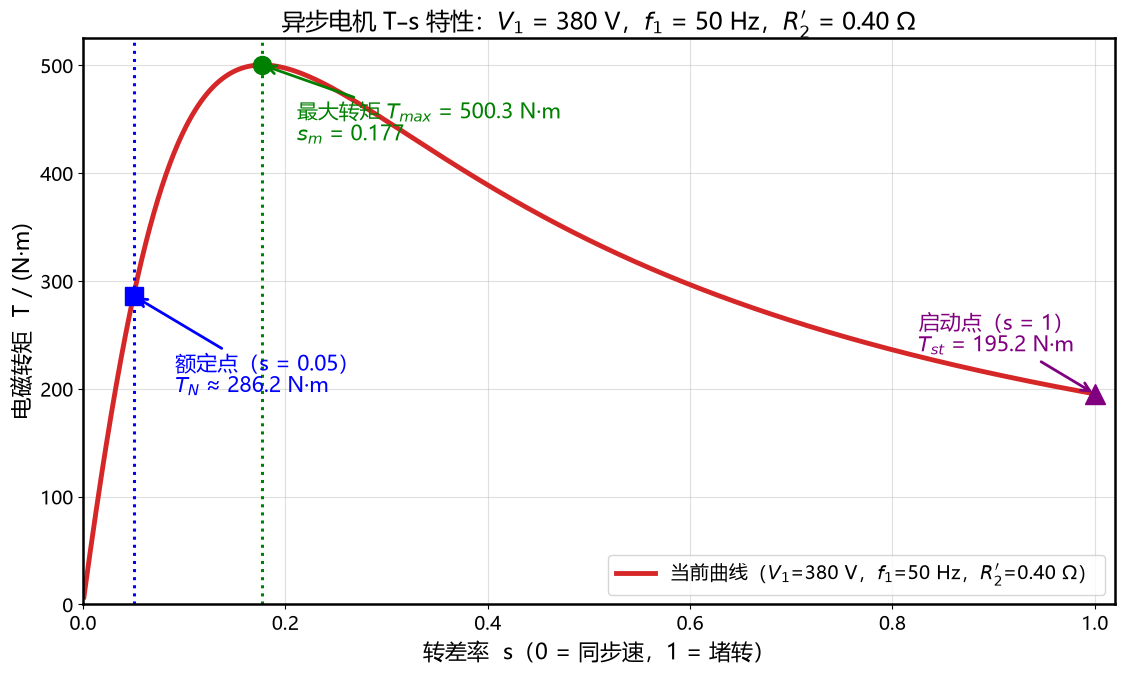

In [6]:
# ================= 静态预览（GitHub 网页 / 打印用） =================
# 说明：交互图绘制在控件 Output 中，GitHub 网页无法渲染；
# 本 cell 用默认参数直接渲染同一张曲线（不叠加灰色对比线），
# 在 GitHub 上浏览 notebook 时也能看到 T-s 特性形状。
T_default = calc_torque(S_ARRAY, V_DEFAULT, F_BASE, R2_DEFAULT)
plot_ts_curve(S_ARRAY, T_default, None, V_DEFAULT, F_BASE, R2_DEFAULT)
plt.show()

## 四、思考题

1. **转子电阻的作用**：保持 V₁ = 380 V、f₁ = 50 Hz，把 R₂′ 从 0.1 Ω 逐步增大到 1.5 Ω。最大转矩的**数值**变了吗？临界转差率 $s_m$ 向哪个方向移动？结合 $s_m = \dfrac{R_2'}{\sqrt{R_1^2+(X_1+X_2')^2}}$，解释为什么绕线转子电机"转子串电阻"可以提高启动转矩。
2. **电压平方效应**：保持 f₁ = 50 Hz，把 V₁ 从 380 V 降到 300 V。先估算启动转矩约变为原来的多少倍，再用曲线验证。这对"电网电压跌落时电机带载能力"意味着什么？
3. **变频调速**：把 f₁ 从 50 Hz 降到 25 Hz，分别在**不勾选**（恒压）与**勾选**（恒 V/f）两种模式下观察最大转矩。① 恒压时最大转矩反而急剧变大——结合磁通 $\Phi \propto V_1/f_1$ 说明此时磁路会发生什么（实际电机会饱和，本模型未计及），为什么不能这样运行？② 恒 V/f 时最大转矩为什么仍略有下降？（提示：电抗随频率减小，而定子电阻 $R_1$ 不变，$R_1$ 在低频时的影响相对变大。）这正是变频器"低频转矩补偿"要解决的问题。

---

## 附：运行方式

```bash
pip install -r requirements.txt          # 安装依赖（numpy / matplotlib / ipywidgets / voila）

jupyter lab                              # Jupyter 交互模式：可编辑、调试

voila 异步电机T-s特性.ipynb               # 演示网页模式：隐藏代码，适合课堂投屏
```

> Voilà 模式下只渲染 Markdown 与交互控件，学生无需看到代码；浏览器中拖动滑块同样实时刷新。